# Aesop AbstractGraph embedding and clustering

This notebook configures and runs the experiment implemented in `experiments/aesop_graph_embeddings_clustering.py`, then displays clustering metrics and representative tales. The module handles corpus loading, graph and embedding checkpoints, vectorization, clustering, and the results manifest.

The default Project Gutenberg edition is titled *Three Hundred Aesop's Fables* and contains 313 indexed tales. This smoke run uses the first 300; set `SMOKE_TEST = False` to process all 313.

Graph extraction and text embeddings use hosted APIs and may incur charges. Install with `pip install -e '.[dev,abstractgraph]'`. Generated data is stored under `data/processed/aesop_abstractgraph/`.


In [4]:
from pathlib import Path
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.aesop_graph_embeddings_clustering import run_experiment

SMOKE_TEST = True
SMOKE_LIMIT = 16
EMBED_NODES = True
EMBEDDING_MODEL = "text-embedding-3-small"
RANDOM_SEED = 17
NBITS = 14

experiment = run_experiment(
    ROOT,
    smoke_test=SMOKE_TEST,
    smoke_limit=SMOKE_LIMIT,
    embed_nodes=EMBED_NODES,
    embedding_model=EMBEDDING_MODEL,
    random_seed=RANDOM_SEED,
    nbits=NBITS,
)
stories = experiment["stories"]
metadata = experiment["metadata"]
graphs = experiment["graphs"]
graph_matrix = experiment["graph_matrix"]
text_matrix = experiment["text_matrix"]
graph_features = experiment["graph_features"]
text_features = experiment["text_features"]
cluster_results = experiment["cluster_results"]
metric_rows = experiment["metric_rows"]
agreement_rows = experiment["agreement_rows"]
max_k = experiment["max_k"]
n_tales = len(stories)
print(f"Tales: {n_tales} | graph vectors: {graph_matrix.shape} | text vectors: {text_matrix.shape}")
print(f"Results manifest: {experiment['manifest_path']}")



Story 1/16: The Lion And The Mouse
--------------------------------------------------------------------------------

Story 2/16: The Wolf And The Lamb
--------------------------------------------------------------------------------

Story 3/16: The Ass And The Grasshopper
--------------------------------------------------------------------------------

Story 4/16: The Wolf and the Crane
--------------------------------------------------------------------------------

Story 5/16: The Father And His Sons
--------------------------------------------------------------------------------

Story 6/16: The Bat And The Weasels
--------------------------------------------------------------------------------
[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-7902b3e9896b] segment: 1 -> 1 | 0.0 ms | input_chars=592, chunk_chars=592
[document-7902b3e9896b chunk-0] summarize: 1 -> 1 | 1335.9 ms
[document-7902b3e9896b chunk-0] normalize

StageOutputError: Invalid extract output (document-6b2911f652c3:chunk-0): relation 'r13' argument 'subject' references unknown object id 'r14'; arguments must reference an entity or relation id from this extraction response

## What the experiment computes

Each tale gets two representations. The graph path extracts an ontology-based semantic graph, optionally embeds its nodes, converts it to an `AbstractGraph`, and sums the node feature rows into one sparse vector per tale. Because this is a sum, graph size and repeated features can affect vector magnitude. The text baseline splits each tale into chunks of up to 6,000 characters, embeds each chunk, and averages the chunk vectors.

Before clustering, the sparse graph vectors are scaled without centering and reduced with TruncatedSVD to at most 50 components. The text vectors are standardized in their original embedding space. KMeans and agglomerative clustering are each run for `k = 2` through `min(8, tales - 1)` on both representations.


## Compare clusterings

Metric scores are inspection aids, not proof of semantic quality. Compare representative tales and boundary cases before drawing conclusions.


In [ ]:
try:
    import pandas as pd
    metrics = pd.DataFrame(metric_rows).sort_values(
        ["representation", "silhouette"], ascending=[True, False]
    )
    display(metrics)
except ImportError:
    display(metric_rows)

for row in agreement_rows:
    print(f"k={row['k']}: ARI={row['ari']:.3f}, NMI={row['nmi']:.3f}")


,representation,algorithm,k,silhouette,calinski_harabasz,davies_bouldin
1,AbstractGraph,kmeans,3,0.200405,2.332947,0.728338
4,AbstractGraph,agglomerative,3,0.200405,2.332947,0.728338
2,AbstractGraph,kmeans,4,0.180296,5.021943,0.257642
5,AbstractGraph,agglomerative,4,0.180296,5.021943,0.257642
0,AbstractGraph,kmeans,2,0.173640,1.971630,1.176756
3,AbstractGraph,agglomerative,2,0.173640,1.971630,1.176756
6,Direct text,kmeans,2,0.068320,1.311344,0.675246
9,Direct text,agglomerative,2,0.068320,1.311344,0.675246
7,Direct text,kmeans,3,0.054549,1.388953,0.607842
10,Direct text,agglomerative,3,0.054549,1.388953,0.607842


k=2: ARI=-0.154, NMI=0.202
k=3: ARI=0.211, NMI=0.671
k=4: ARI=-0.111, NMI=0.792


## How to read the scores

- **Silhouette** ranges from −1 to 1; higher means points are closer to their own cluster than to neighboring clusters. Values near 0 suggest overlap, and negative values can indicate poor assignments.
- **Calinski–Harabasz** compares between-cluster spread with within-cluster spread; higher is generally better.
- **Davies–Bouldin** measures how similar clusters are to their nearest neighboring cluster; lower is generally better.

Use these scores to compare choices within the same representation. Graph and text vectors live in different feature spaces, so their score magnitudes are not directly comparable. The ARI and NMI lines compare the *assignments* from graph and text KMeans at the same `k`: ARI is 1 for identical partitions and about 0 for chance-level agreement; NMI ranges from 0 (no shared information) to 1 (identical partitions). Agreement does not establish that either clustering is correct.


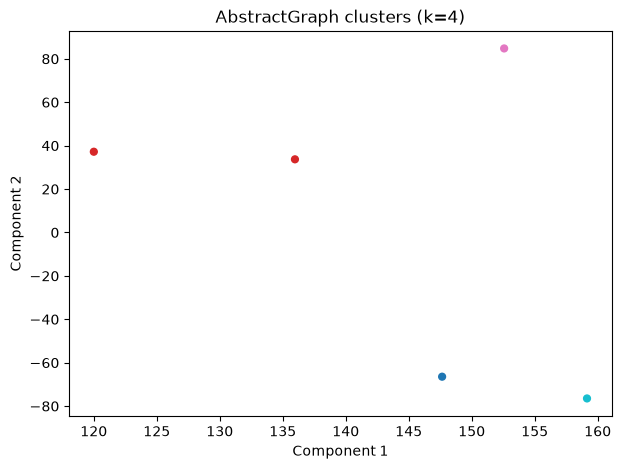

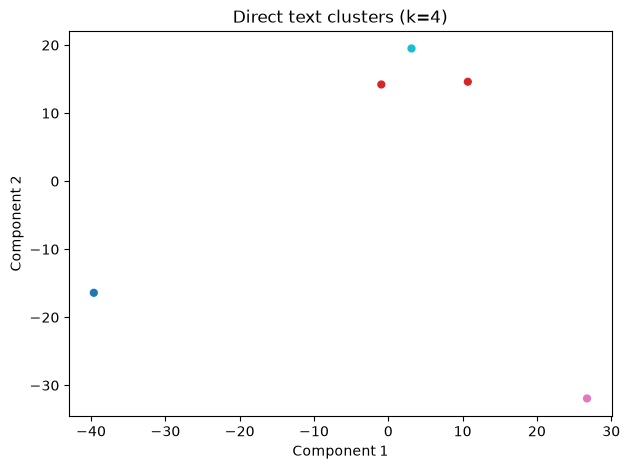

### Cluster 0 (1 tales) — representative: The Wolf And The Lamb


The Wolf And The Lamb (aesop-0001-a72355949ffb)
The Wolf And The Lamb


WOLF, meeting with a Lamb astray from the fold, resolved not to lay
violent hands on him, but to find some plea to justify to the Lamb the
Wolf’s right to eat him. He thus addressed him: “Sirrah, last year you
grossly insulted me.” “Indeed,” bleated the Lamb in a mournful tone of
voice, “I was not then born.” Then said the Wolf, “You feed in my
pasture.” “No, good sir,” replied the Lamb, “I have not yet tasted
grass.” Again said the Wolf, “You drink of my well.” “No,” exclaimed
the Lamb, “I never yet drank water, for as yet my mother’s milk is both
food and drink to me.” Upon which the Wolf seized him and ate him up,
saying, “Well! I won’t remain supperless, even though you refute every
one of my imputations.” The tyrant will always find a pretext for his
tyranny.

Representative graph summary:
Entity types: [('Action', 23), ('Animal', 3), ('Moral', 2), ('Trait', 1)]
Relations: [('performs', 11), ('has_trait', 1),

### Cluster 1 (2 tales) — representative: The Ass And The Grasshopper


The Ass And The Grasshopper (aesop-0002-932912a3e124)
The Ass And The Grasshopper


AN ASS having heard some Grasshoppers chirping, was highly enchanted;
and, desiring to possess the same charms of melody, demanded what sort
of food they lived on to give them such beautiful voices. They replied,
“The dew.” The Ass resolved that he would live only upon dew, and in a
short time died of hunger.

The Wolf and the Crane (aesop-0003-192d80ea9aa8)
The Wolf and the Crane


A WOLF who had a bone stuck in his throat hired a Crane, for a large
sum, to put her head into his mouth and draw out the bone. When the
Crane had extracted the bone and demanded the promised payment, the
Wolf, grinning and grinding his teeth, exclaimed: “Why, you have surely
already had a sufficient recompense, in having been permitted to draw
out your head in safety from the mouth and jaws of a wolf.”

In serving the wicked, expect no reward, and be thankful if you escape
injury for your pains.

Representative graph summa

### Cluster 2 (1 tales) — representative: The Father And His Sons


The Father And His Sons (aesop-0004-c731227fcc91)
The Father And His Sons


A FATHER had a family of sons who were perpetually quarreling among
themselves. When he failed to heal their disputes by his exhortations,
he determined to give them a practical illustration of the evils of
disunion; and for this purpose he one day told them to bring him a
bundle of sticks. When they had done so, he placed the faggot into the
hands of each of them in succession, and ordered them to break it in
pieces. They tried with all their strength, and were not able to do it.
He next opened the faggot, took the sticks separately, one by one, and
again put them into his sons’ hands, upon which they broke them easily.
He then addressed them in these words: “My sons, if you are of one
mind, and unite to assist each other, you will be as this faggot,
uninjured by all the attempts of your enemies; but if you are divided
among yourselves, you will be broken as easily as these sticks.”

Representative graph summ

### Cluster 3 (1 tales) — representative: The Lion And The Mouse


The Lion And The Mouse (aesop-0000-fbdceb1ca5cd)
The Lion And The Mouse


A LION was awakened from sleep by a Mouse running over his face. Rising
up angrily, he caught him and was about to kill him, when the Mouse
piteously entreated, saying: “If you would only spare my life, I would
be sure to repay your kindness.” The Lion laughed and let him go. It
happened shortly after this that the Lion was caught by some hunters,
who bound him by strong ropes to the ground. The Mouse, recognizing his
roar, came and gnawed the rope with his teeth, and set him free,
exclaiming:

“You ridiculed the idea of my ever being able to help you, not
expecting to receive from me any repayment of your favour; now you know
that it is possible for even a Mouse to confer benefits on a Lion.”

Representative graph summary:
Entity types: [('Action', 19), ('Human', 3), ('Animal', 2), ('Goal', 2), ('Moral', 2), ('Trait', 1)]
Relations: [('performs', 9), ('wants', 2), ('has_trait', 1), ('teaches', 1), ('before', 1)

In [ ]:
from textwrap import wrap

def print_wrapped_story(text, width=80):
    for paragraph in text.splitlines():
        wrapped = wrap(paragraph, width=width)
        print("\n".join(wrapped))

selected_k = min(4, n_tales - 1)
for representation, features, reducer in (
    ("AbstractGraph", graph_features, None),
    ("Direct text", text_features, PCA(n_components=2, random_state=RANDOM_SEED)),
):
    coordinates = reducer.fit_transform(features) if reducer is not None else features[:, :2]
    labels = cluster_results[(representation, "kmeans", selected_k)]
    plt.figure(figsize=(7, 5))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], c=labels, cmap="tab10", s=24)
    plt.title(f"{representation} clusters (k={selected_k})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

labels = cluster_results[("AbstractGraph", "kmeans", selected_k)]
for label in sorted(set(labels)):
    members = np.flatnonzero(labels == label)
    distances = pairwise_distances(graph_features[members], metric="euclidean")
    medoid_index = members[int(np.argmin(distances.mean(axis=1)))]
    display(Markdown(
        f"### Cluster {label} ({len(members)} tales) — "
        f"representative: {metadata[medoid_index]['title']}"
    ))
    for member_index in members:
        row = metadata[member_index]
        print(f"\n{row['title']} ({row['tale_id']})")
        print_wrapped_story(stories[member_index], width=80)
    graph = graphs[medoid_index]
    entity_types = Counter(data.get("type") for _node, data in graph.nodes(data=True))
    relation_names = Counter(
        data.get("relation") for _node, data in graph.nodes(data=True)
        if data.get("relation")
    )
    argument_roles = Counter(
        data.get("role") for _source, _target, data in graph.edges(data=True)
    )
    print("\nRepresentative graph summary:")
    print("Entity types:", entity_types.most_common(6))
    print("Relations:", relation_names.most_common(6))
    print("Argument roles:", argument_roles.most_common(6))


## How to read the plots and tale examples

Colors show KMeans assignments for `selected_k`. Graph coordinates are the first two SVD features; text coordinates come from PCA. The axes have no direct semantic meaning, and positions should only be interpreted within each plot.

For each graph cluster, the notebook prints every member tale. The listed representative is the **medoid**: the tale with the lowest average Euclidean distance to the other members in the reduced graph feature space. Its entity-type, relation, and argument-role counts give a quick structural profile of that representative; they are not cluster-wide totals.

These are exploratory, unsupervised results. Model extraction errors, embedding choices, corpus size, and feature scaling can all change the clusters. Read the tales and inspect borderline cases before treating a pattern as meaningful.


Inspect excerpts, recurring entity types, relations, argument roles, nearest tales, and boundary cases. The manifest records the corpus/configuration hashes and results alongside the cached graph artifacts.
